In [4]:
import cv2
import requests
import numpy as np
from PIL import Image
from io import BytesIO

def get_image(img_url):
  response = requests.get(img_url)
  return Image.open(BytesIO(response.content)).convert('RGB')

def image_selection(img):
  img = np.array(img)
  img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  L = np.mean(img_gray) # Яркость
  contrast = img_gray.std() # Контраст

  hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
  saturation = np.mean(hsv[:, :, 1]) # Насыщенность
  hue = np.mean(hsv[:, :, 0]) # тон
  laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
  cool = laplacian.var() # четкость 🤘 (резкость)

  mean_r = np.mean(img[:, :, 0])
  mean_g = np.mean(img[:, :, 1])
  mean_b = np.mean(img[:, :, 2])
  return {
      'light': L,
      'contrast': contrast,
      'saturation' : saturation,
      'hue': hue,
      'clarity': cool,
      'mean_r' : mean_r,
      'mean_g': mean_g,
      'mean_b': mean_b
      }

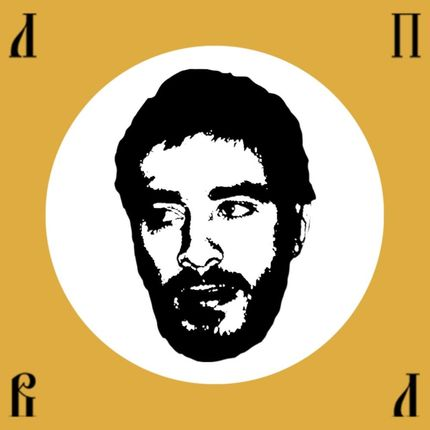

In [5]:
image_url = 'https://t2.genius.com/unsafe/430x430/https%3A%2F%2Fimages.genius.com%2F534833b231282b8a0e562ff6d42ba2e0.1000x1000x1.jpg'  # или song['song_art_image_url'] или song['header_image_url']
img = get_image(image_url)
img

In [6]:
d = image_selection(img)
d

{'light': np.float64(172.44021092482424),
 'contrast': np.float64(82.35261683371449),
 'saturation': np.float64(93.2929096809086),
 'hue': np.float64(14.43260681449432),
 'clarity': np.float64(1181.0784532179557),
 'mean_r': np.float64(196.42212547322876),
 'mean_g': np.float64(170.9724986479178),
 'mean_b': np.float64(117.25688480259599)}

In [ ]:
# я думаю нужно нормализовать эти признаки

In [ ]:
"""
Источники:
https://qna.habr.com/q/681879
https://stackoverflow.com/questions/596216/formula-to-determine-perceived-brightness-of-rgb-color
https://stackoverflow.com/questions/58821130/how-to-calculate-the-contrast-of-an-image
https://en.wikipedia.org/wiki/HSL_and_HSV
https://ru.wikipedia.org/wiki/HSV_(цветовая_модель)
https://forum.opencv.org/t/scoring-the-clarity-of-an-image/16268
"""